# Wind Farm C — Comprehensive EDA
## CARE To Compare Benchmark: Pre-Failure Detection

**Goal:** Understand the data deeply before modeling. We need to detect anomalies (early signs of failure) in wind turbine SCADA data.

### Dataset Overview
- **58 CSV files** (one per event) — each ~300MB
- **27 anomaly events**, **31 normal events**
- **239 sensors** × 4 statistics (avg, max, min, std) = **957 features** + metadata
- **10-minute intervals** of SCADA readings
- Each file has a `train` and `prediction` split

---

## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# --- Paths ---
BASE_DIR = Path('CARE_To_Compare/Wind Farm C')
DATASET_DIR = BASE_DIR / 'datasets'
EVENT_INFO_PATH = BASE_DIR / 'event_info.csv'
FEATURE_DESC_PATH = BASE_DIR / 'feature_description.csv'

print(f'Dataset directory: {DATASET_DIR}')
print(f'Number of CSV files: {len(list(DATASET_DIR.glob("*.csv")))}')

Dataset directory: CARE_To_Compare/Wind Farm C/datasets
Number of CSV files: 58


## 2. Load Event Info & Feature Descriptions

In [2]:
# --- Event Info ---
event_df = pd.read_csv(EVENT_INFO_PATH, sep=';',
                       parse_dates=['event_start', 'event_end'], dayfirst=True)
print(f'Total events: {len(event_df)}')
print(f'Anomaly events: {(event_df["event_label"] == "anomaly").sum()}')
print(f'Normal events:  {(event_df["event_label"] == "normal").sum()}')
print()

event_df.head(10)

Total events: 58
Anomaly events: 27
Normal events:  31



,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,55,anomaly,2018-10-29 11:30:00,52848,2018-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,81,anomaly,2019-11-17 01:30:00,52704,2019-11-19 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,47,anomaly,2018-12-23 15:00:00,52416,2018-12-28 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,12,anomaly,2025-06-25 00:00:00,52560,2025-07-17 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,4,anomaly,2026-07-29 10:00:00,52992,2026-08-17 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,18,anomaly,2025-09-12 00:00:00,51408,2025-09-15 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,28,anomaly,2023-05-27 13:00:00,52704,2023-06-16 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,39,anomaly,2022-10-18 13:00:00,52848,2022-10-23 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,66,anomaly,2029-01-15 00:00:00,51696,2029-01-21 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,15,anomaly,2019-02-07 00:00:00,51984,2019-02-24 00:00:00,54432,Randomn small failures regarding pitch resulti...


Total sensors: 238
Angle sensors: 12
Counter sensors: 0



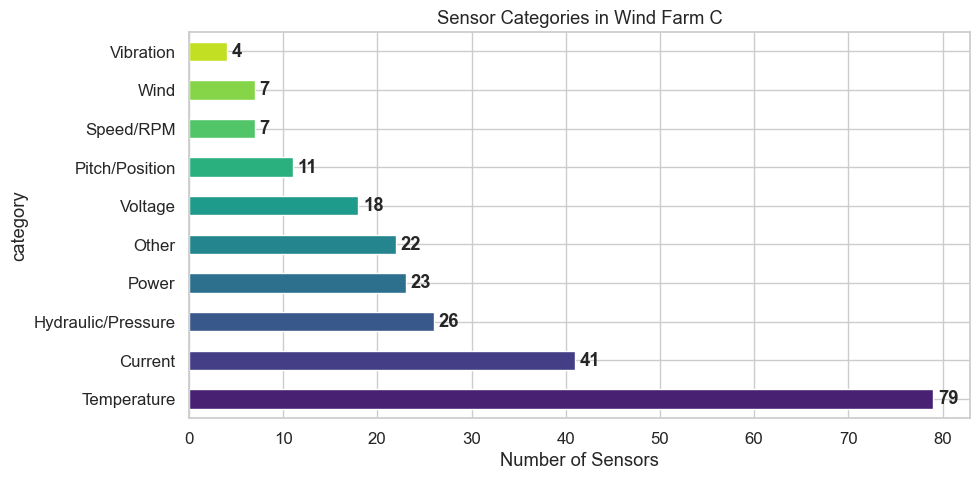

,sensor_name,description,unit,category
0,sensor_0,"ABB-LS Input K1, IL1",A,Other
1,sensor_1,Generator acceleration,rpm/s,Other
2,power_2,ABB-LS Active Power,kW,Power
3,sensor_3,Active power aeration motor A,%,Power
4,sensor_4,Active power aeration motor B,%,Power
5,power_5,Active power grid side converter,kW,Power
6,power_6,Active power HV grid,kW,Power
7,sensor_7,Ambient temperature,Celsius,Temperature
8,sensor_8,Generator angle speed,rad/s,Speed/RPM
9,sensor_9,Battery charge 1,A,Other


In [3]:
# --- Feature Descriptions ---
feat_desc = pd.read_csv(FEATURE_DESC_PATH, sep=';')
print(f'Total sensors: {len(feat_desc)}')
print(f'Angle sensors: {feat_desc["is_angle"].sum()}')
print(f'Counter sensors: {feat_desc["is_counter"].sum()}')
print()

# Categorize sensors by domain
feat_desc['desc_lower'] = feat_desc['description'].str.lower()

def categorize_sensor(desc):
    desc = desc.lower()
    if any(k in desc for k in ['temperature', 'temp', 'cooling']):
        return 'Temperature'
    elif any(k in desc for k in ['power', 'active power', 'reactive power', 'consumption']):
        return 'Power'
    elif any(k in desc for k in ['current', 'rms current']):
        return 'Current'
    elif any(k in desc for k in ['voltage', 'vdc']):
        return 'Voltage'
    elif any(k in desc for k in ['wind speed', 'wind direction']):
        return 'Wind'
    elif any(k in desc for k in ['vibration']):
        return 'Vibration'
    elif any(k in desc for k in ['hydraulic', 'pressure', 'oil']):
        return 'Hydraulic/Pressure'
    elif any(k in desc for k in ['pitch', 'axis', 'rotor blade', 'position']):
        return 'Pitch/Position'
    elif any(k in desc for k in ['speed', 'rpm', 'rotational']):
        return 'Speed/RPM'
    elif any(k in desc for k in ['yaw']):
        return 'Yaw'
    else:
        return 'Other'

feat_desc['category'] = feat_desc['description'].apply(categorize_sensor)

cat_counts = feat_desc['category'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(cat_counts)))
ax.set_xlabel('Number of Sensors')
ax.set_title('Sensor Categories in Wind Farm C')
for i, v in enumerate(cat_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

feat_desc[['sensor_name', 'description', 'unit', 'category']].head(20)

## 3. Event Duration & Label Analysis

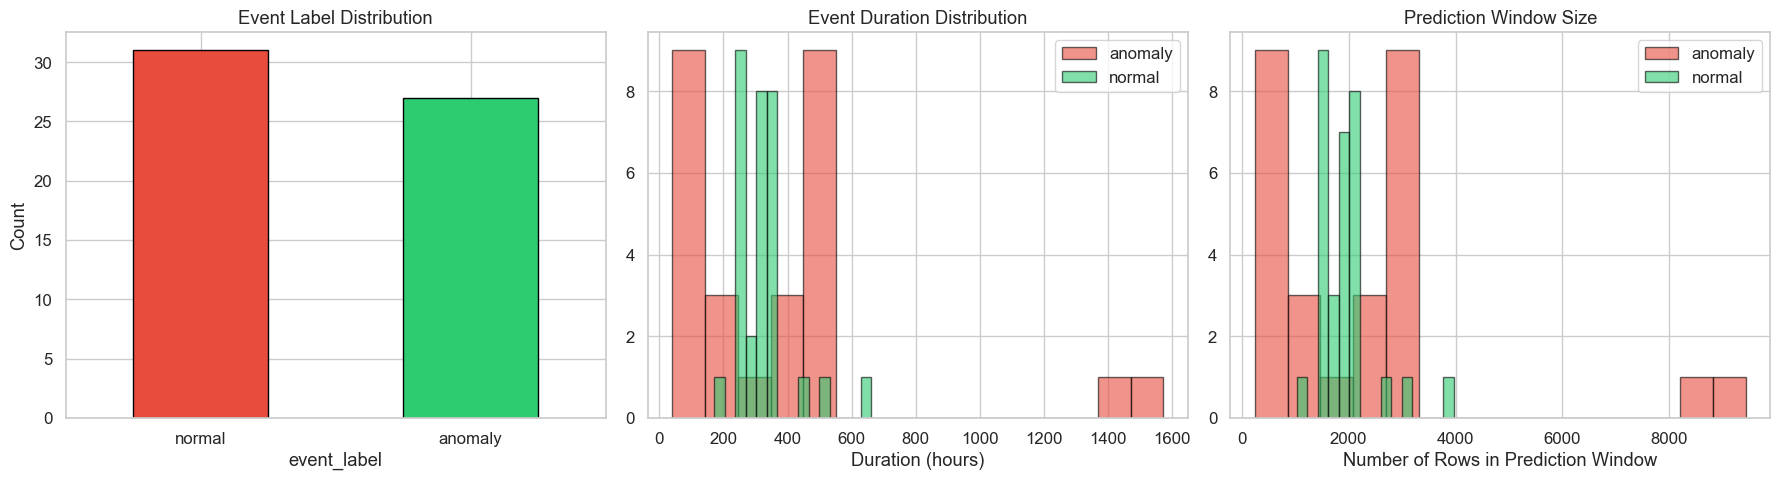


--- Event Duration Stats (hours) ---
             count   mean    std    min    25%    50%    75%     max
event_label                                                         
anomaly       27.0  375.7  369.9   40.8  109.1  359.8  485.5  1572.3
normal        31.0  318.8   91.9  171.8  264.0  312.0  336.0   661.5


In [5]:
# Event duration
event_df['duration_hours'] = (event_df['event_end'] - event_df['event_start']).dt.total_seconds() / 3600
event_df['predict_rows'] = event_df['event_end_id'] - event_df['event_start_id']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Label distribution
event_df['event_label'].value_counts().plot(kind='bar', ax=axes[0], 
    color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Event Label Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# 2. Event duration by label
for label, color in [('anomaly', '#e74c3c'), ('normal', '#2ecc71')]:
    subset = event_df[event_df['event_label'] == label]
    axes[1].hist(subset['duration_hours'], bins=15, alpha=0.6, label=label, color=color, edgecolor='black')
axes[1].set_xlabel('Duration (hours)')
axes[1].set_title('Event Duration Distribution')
axes[1].legend()

# 3. Prediction window size
for label, color in [('anomaly', '#e74c3c'), ('normal', '#2ecc71')]:
    subset = event_df[event_df['event_label'] == label]
    axes[2].hist(subset['predict_rows'], bins=15, alpha=0.6, label=label, color=color, edgecolor='black')
axes[2].set_xlabel('Number of Rows in Prediction Window')
axes[2].set_title('Prediction Window Size')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\n--- Event Duration Stats (hours) ---')
print(event_df.groupby('event_label')['duration_hours'].describe().round(1))

In [6]:
# Anomaly event descriptions (failure types)
anomaly_events = event_df[event_df['event_label'] == 'anomaly'][['event_id', 'event_description', 'duration_hours']]
anomaly_events = anomaly_events.sort_values('duration_hours', ascending=False)
print(f'\n=== Anomaly Events ({len(anomaly_events)} total) ===')
for _, row in anomaly_events.iterrows():
    desc = row['event_description'][:120] + '...' if len(str(row['event_description'])) > 120 else row['event_description']
    print(f"  Event {row['event_id']:3d} | {row['duration_hours']:7.1f}h | {desc}")


=== Anomaly Events (27 total) ===
  Event  44 |  1572.3h | Valve in water cooling system was left in wrong position after maintenance actions on 05-08-2020
  Event  67 |  1392.0h | Turbine has some issues with overpressure on the main transformer
  Event  30 |   543.7h | Pitch failure - defect fan on pitch motor
  Event  12 |   543.0h | 10115 : Oil level error, two-pump mode + Oil Leakage Gear Oil Supply + 12019: Rotor brake B cannot be closed + P20_yaw c...
  Event  11 |   526.0h | P20_DGUV-v3 RCD 28F1 NC310 defective + 0 : P20_Blades_Cabinet Caps missing
  Event   9 |   506.0h | PENDING19_PREV_YAW_Grease pump defective
  Event  28 |   487.5h | P20_spinner_carbonbrush defekt + P20_Accumulators_hydraulic system
  Event  70 |   483.5h | 21002 : Axis 1 DC-link voltage low, batt
  Event  91 |   482.5h | 23020 : Axis 3 not ready-to-operate
  Event  33 |   480.0h | P20_Blade3_Grease Collector missing
  Event   4 |   456.0h | 23020 : Axis 3 not ready-to-operate
  Event  55 |   412.0h | Hart

## 4. Load & Profile Sample Datasets
We load 4 representative datasets (2 anomaly + 2 normal) to understand the structure.

In [7]:
def load_dataset(event_id):
    """Load a single dataset CSV and return it with event metadata."""
    path = DATASET_DIR / f'{event_id}.csv'
    df = pd.read_csv(path, sep=';', parse_dates=['time_stamp'])
    event_row = event_df[event_df['event_id'] == event_id].iloc[0]
    return df, event_row

# Select 2 anomaly + 2 normal events
sample_anomaly_ids = event_df[event_df['event_label'] == 'anomaly']['event_id'].values[:2]
sample_normal_ids = event_df[event_df['event_label'] == 'normal']['event_id'].values[:2]
sample_ids = list(sample_anomaly_ids) + list(sample_normal_ids)

print(f'Loading sample datasets: {sample_ids}')
print(f'  Anomaly: {list(sample_anomaly_ids)}')
print(f'  Normal:  {list(sample_normal_ids)}')

# Load first one for detailed profiling
df_sample, event_sample = load_dataset(sample_ids[0])
print(f'\n--- Dataset {sample_ids[0]} ---')
print(f'Shape: {df_sample.shape}')
print(f'Columns: {df_sample.shape[1]}')
print(f'Memory: {df_sample.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Label: {event_sample["event_label"]}')
print(f'Train rows: {(df_sample["train_test"] == "train").sum()}')
print(f'Predict rows: {(df_sample["train_test"] == "prediction").sum()}')
df_sample.head(3)

Loading sample datasets: [np.int64(55), np.int64(81), np.int64(8), np.int64(85)]
  Anomaly: [np.int64(55), np.int64(81)]
  Normal:  [np.int64(8), np.int64(85)]

--- Dataset 55 ---
Shape: (55753, 957)
Columns: 957
Memory: 429.9 MB
Label: anomaly
Train rows: 52560
Predict rows: 3193


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,...,wind_speed_236_min,wind_speed_236_std,wind_speed_235_avg,wind_speed_235_max,wind_speed_235_min,wind_speed_235_std,wind_speed_237_avg,wind_speed_237_max,wind_speed_237_min,wind_speed_237_std
0,2017-10-27 11:30:00,50,0,train,0,88.531,92.3,83.9,1.483,-0.0023,...,9.05,1.177,13.067,16.5,7.0,1.242,13.404,17.4,7.0,1.458
1,2017-10-27 11:40:00,50,1,train,0,88.453,94.3,83.9,1.651,0.0037,...,8.95,1.268,13.375,16.6,8.1,1.276,13.778,18.4,7.7,1.614
2,2017-10-27 11:50:00,50,2,train,0,88.376,92.0,84.8,1.497,-0.0006,...,6.95,1.415,12.775,16.5,6.8,1.493,13.125,17.0,5.6,1.654


In [8]:
# Metadata columns vs sensor columns
meta_cols = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
sensor_cols = [c for c in df_sample.columns if c not in meta_cols]

print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Sensor columns: {len(sensor_cols)}')
print(f'\nData types:')
print(df_sample[meta_cols].dtypes)
print(f'\nUnique asset_ids: {df_sample["asset_id"].unique()}')
print(f'Unique status_type_ids: {sorted(df_sample["status_type_id"].unique())}')

Metadata columns (5): ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
Sensor columns: 952

Data types:
time_stamp        datetime64[ns]
asset_id                   int64
id                         int64
train_test                object
status_type_id             int64
dtype: object

Unique asset_ids: [50]
Unique status_type_ids: [np.int64(0), np.int64(3), np.int64(4), np.int64(5)]


## 5. Missing Values & Data Quality

=== Data Quality Report (Event 55) ===
Total sensor columns: 952
Columns with ANY missing: 0
Columns with >50% missing: 0
Columns with >80% zeros: 39
Constant columns (0 variance): 4


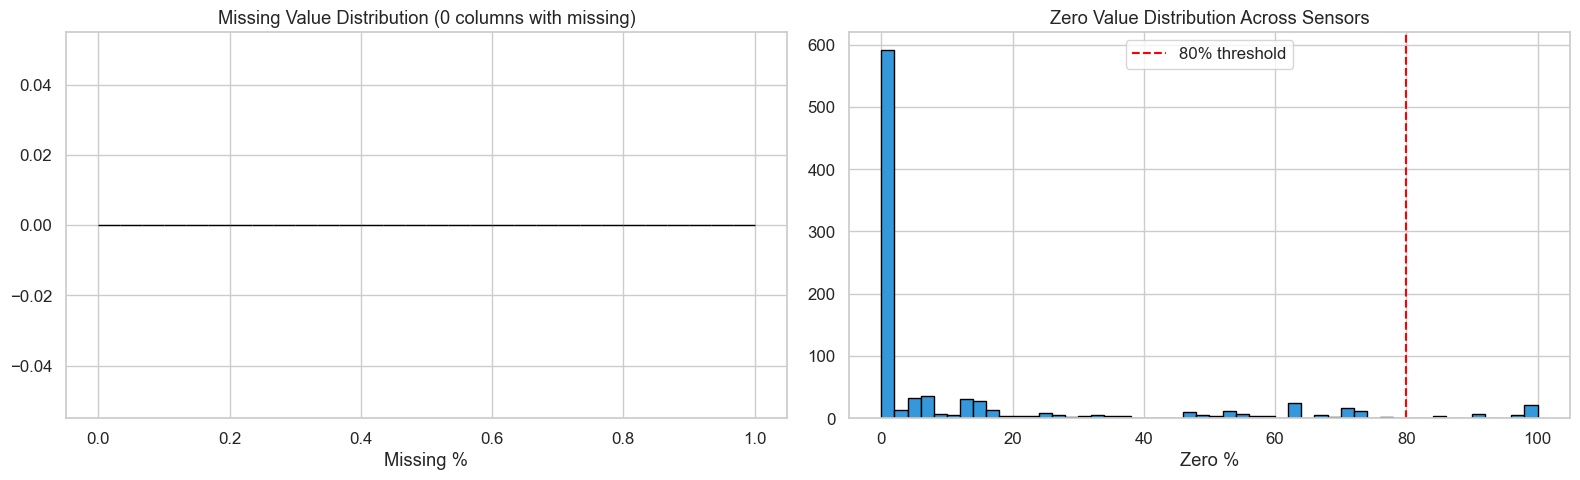

In [9]:
# Missing value analysis
missing_pct = df_sample[sensor_cols].isnull().mean() * 100
zero_pct = (df_sample[sensor_cols] == 0).mean() * 100
constant_cols = [c for c in sensor_cols if df_sample[c].nunique() <= 1]

print(f'=== Data Quality Report (Event {sample_ids[0]}) ===')
print(f'Total sensor columns: {len(sensor_cols)}')
print(f'Columns with ANY missing: {(missing_pct > 0).sum()}')
print(f'Columns with >50% missing: {(missing_pct > 50).sum()}')
print(f'Columns with >80% zeros: {(zero_pct > 80).sum()}')
print(f'Constant columns (0 variance): {len(constant_cols)}')

# Plot missing & zero percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(missing_pct[missing_pct > 0], bins=30, color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Missing %')
axes[0].set_title(f'Missing Value Distribution ({(missing_pct > 0).sum()} columns with missing)')

axes[1].hist(zero_pct, bins=50, color='#3498db', edgecolor='black')
axes[1].set_xlabel('Zero %')
axes[1].set_title('Zero Value Distribution Across Sensors')
axes[1].axvline(80, color='red', linestyle='--', label='80% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Check consistency across multiple datasets
print('=== Cross-Dataset Consistency Check ===')
for eid in sample_ids:
    df_temp, ev_temp = load_dataset(eid)
    miss = df_temp[sensor_cols].isnull().mean() * 100
    zeros = (df_temp[sensor_cols] == 0).mean() * 100
    n_train = (df_temp['train_test'] == 'train').sum()
    n_pred = (df_temp['train_test'] == 'prediction').sum()
    print(f"  Event {eid:3d} [{ev_temp['event_label']:7s}] | "
          f"Shape: {df_temp.shape} | Train: {n_train} | Pred: {n_pred} | "
          f"Miss>0: {(miss>0).sum()} | Zero>80%: {(zeros>80).sum()} | "
          f"Asset: {df_temp['asset_id'].iloc[0]}")
    del df_temp

=== Cross-Dataset Consistency Check ===
  Event  55 [anomaly] | Shape: (55753, 957) | Train: 52560 | Pred: 3193 | Miss>0: 0 | Zero>80%: 39 | Asset: 50
  Event  81 [anomaly] | Shape: (53932, 957) | Train: 52560 | Pred: 1372 | Miss>0: 0 | Zero>80%: 49 | Asset: 38
  Event   8 [normal ] | Shape: (54802, 957) | Train: 52560 | Pred: 2242 | Miss>0: 0 | Zero>80%: 39 | Asset: 50
  Event  85 [normal ] | Shape: (52417, 957) | Train: 50832 | Pred: 1585 | Miss>0: 0 | Zero>80%: 52 | Asset: 14


## 6. Status Type Analysis
The `status_type_id` column indicates the turbine's operational state. This is crucial for filtering healthy operation.

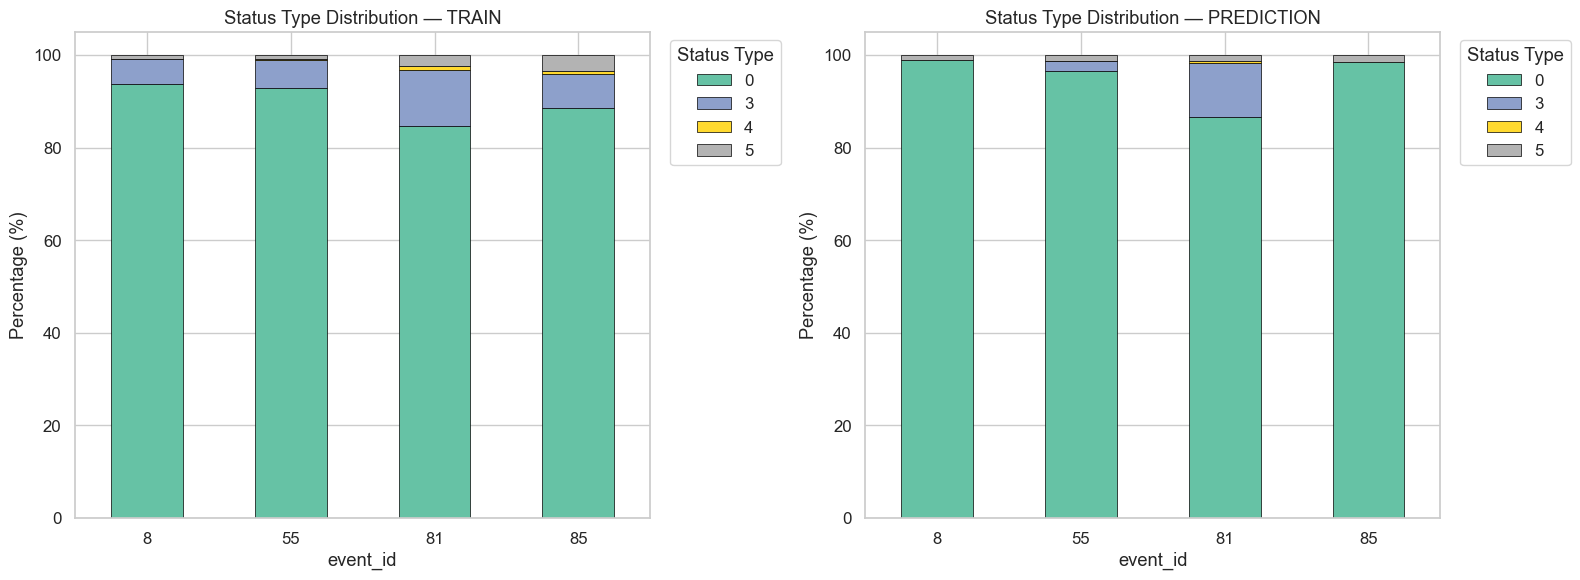


Status Type Legend (typical):
  0 = Normal operation
  2 = Partial operation / curtailed
  4 = Maintenance / downtime
  Others = Various fault/warning states


In [11]:
# Status type distribution across datasets
status_data = []
for eid in sample_ids:
    df_t, ev_t = load_dataset(eid)
    for split in ['train', 'prediction']:
        sub = df_t[df_t['train_test'] == split]
        counts = sub['status_type_id'].value_counts(normalize=True) * 100
        for sid, pct in counts.items():
            status_data.append({'event_id': eid, 'label': ev_t['event_label'],
                                'split': split, 'status_type_id': sid, 'pct': pct})
    del df_t

status_df = pd.DataFrame(status_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, split in enumerate(['train', 'prediction']):
    sub = status_df[status_df['split'] == split]
    pivot = sub.pivot_table(index='event_id', columns='status_type_id', values='pct', fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Status Type Distribution — {split.upper()}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Status Type', bbox_to_anchor=(1.02, 1))
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nStatus Type Legend (typical):')
print('  0 = Normal operation')
print('  2 = Partial operation / curtailed')
print('  4 = Maintenance / downtime')
print('  Others = Various fault/warning states')

## 7. Power Curve Analysis
The relationship between wind speed and power output is the fundamental health indicator.

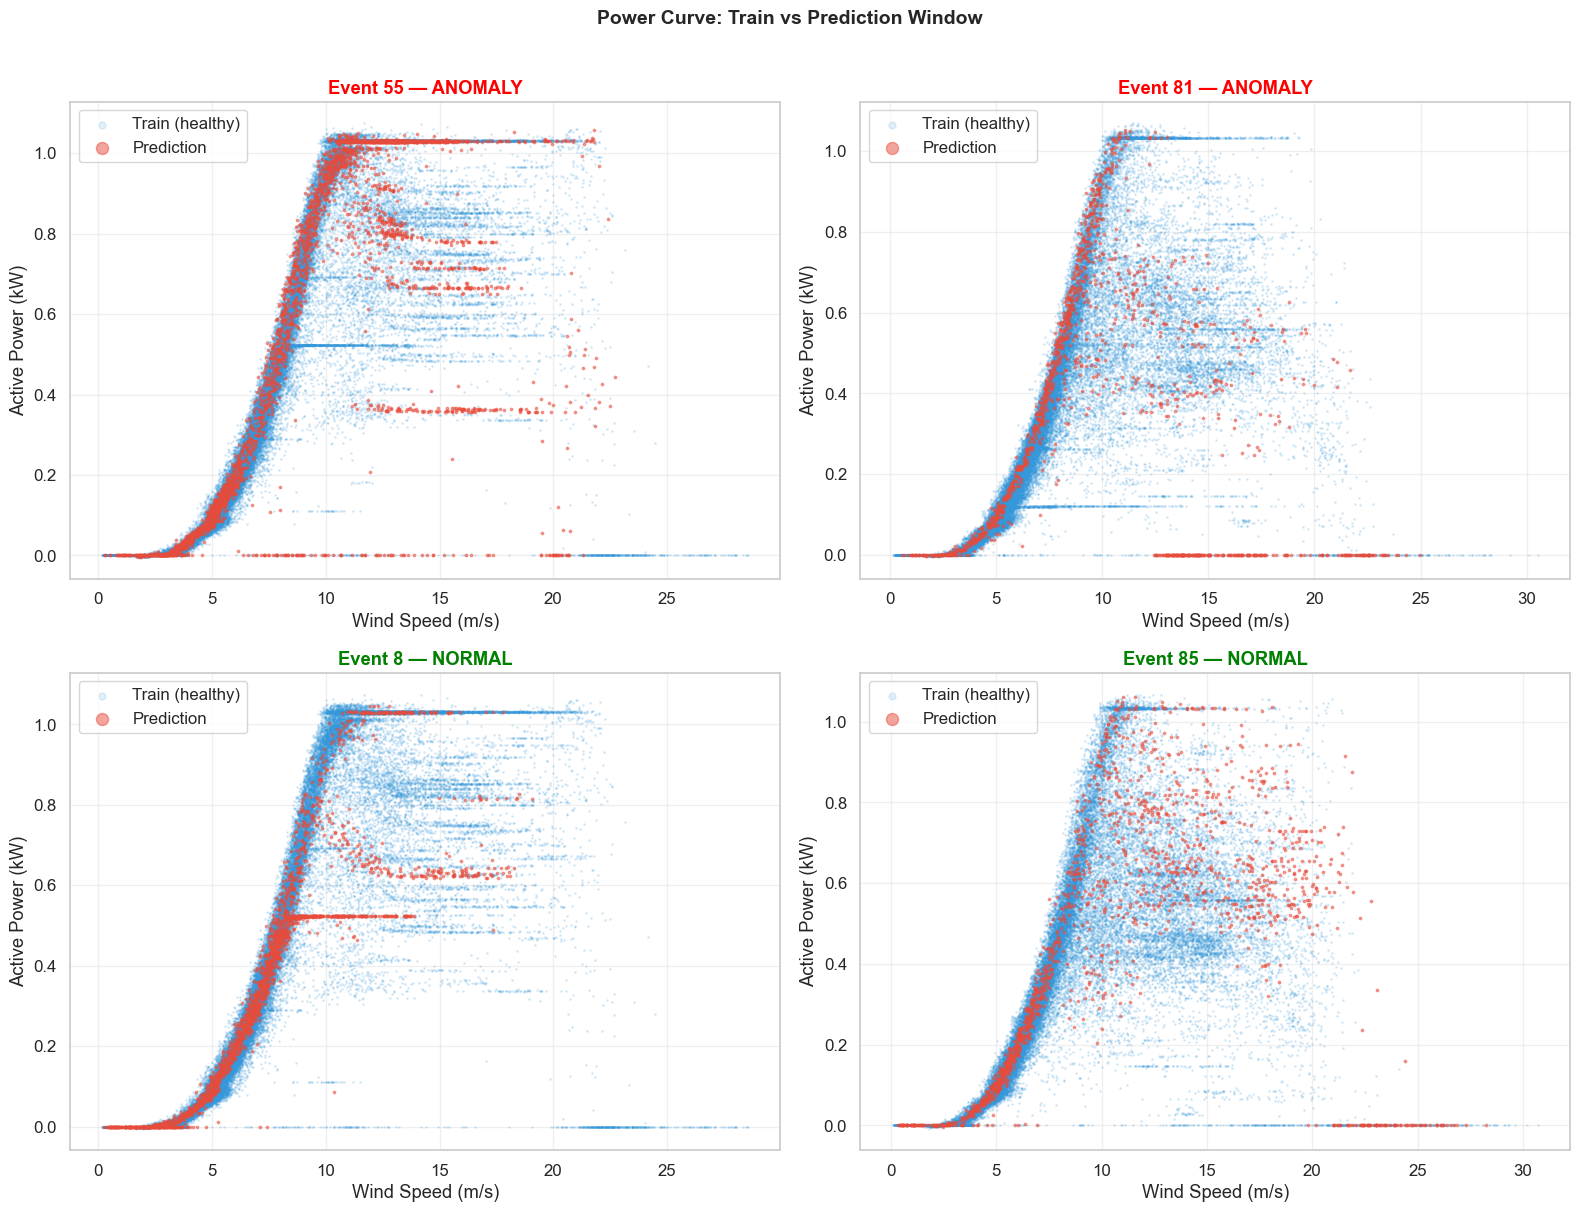

In [12]:
# Power curve: train vs prediction for anomaly and normal events
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, eid in enumerate(sample_ids):
    df_t, ev_t = load_dataset(eid)
    ax = axes[idx // 2, idx % 2]
    
    # Use wind_speed_236_avg (Wind speed 1+2 average) and power_2_avg (Active Power)
    ws_col = 'wind_speed_236_avg'
    pw_col = 'power_2_avg'
    
    train = df_t[df_t['train_test'] == 'train']
    pred = df_t[df_t['train_test'] == 'prediction']
    
    # Filter to healthy operation for cleaner view
    train_h = train[train['status_type_id'] == 0]
    
    ax.scatter(train_h[ws_col], train_h[pw_col], s=1, alpha=0.15, c='#3498db', label='Train (healthy)')
    ax.scatter(pred[ws_col], pred[pw_col], s=3, alpha=0.5, c='#e74c3c', label='Prediction')
    
    color = 'red' if ev_t['event_label'] == 'anomaly' else 'green'
    ax.set_title(f"Event {eid} — {ev_t['event_label'].upper()}", color=color, fontweight='bold')
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Active Power (kW)')
    ax.legend(loc='upper left', markerscale=5)
    ax.grid(True, alpha=0.3)
    
    del df_t

plt.suptitle('Power Curve: Train vs Prediction Window', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Key Sensor Time Series — Anomaly vs Normal
Compare how critical sensors behave in the prediction window for anomaly vs normal events.

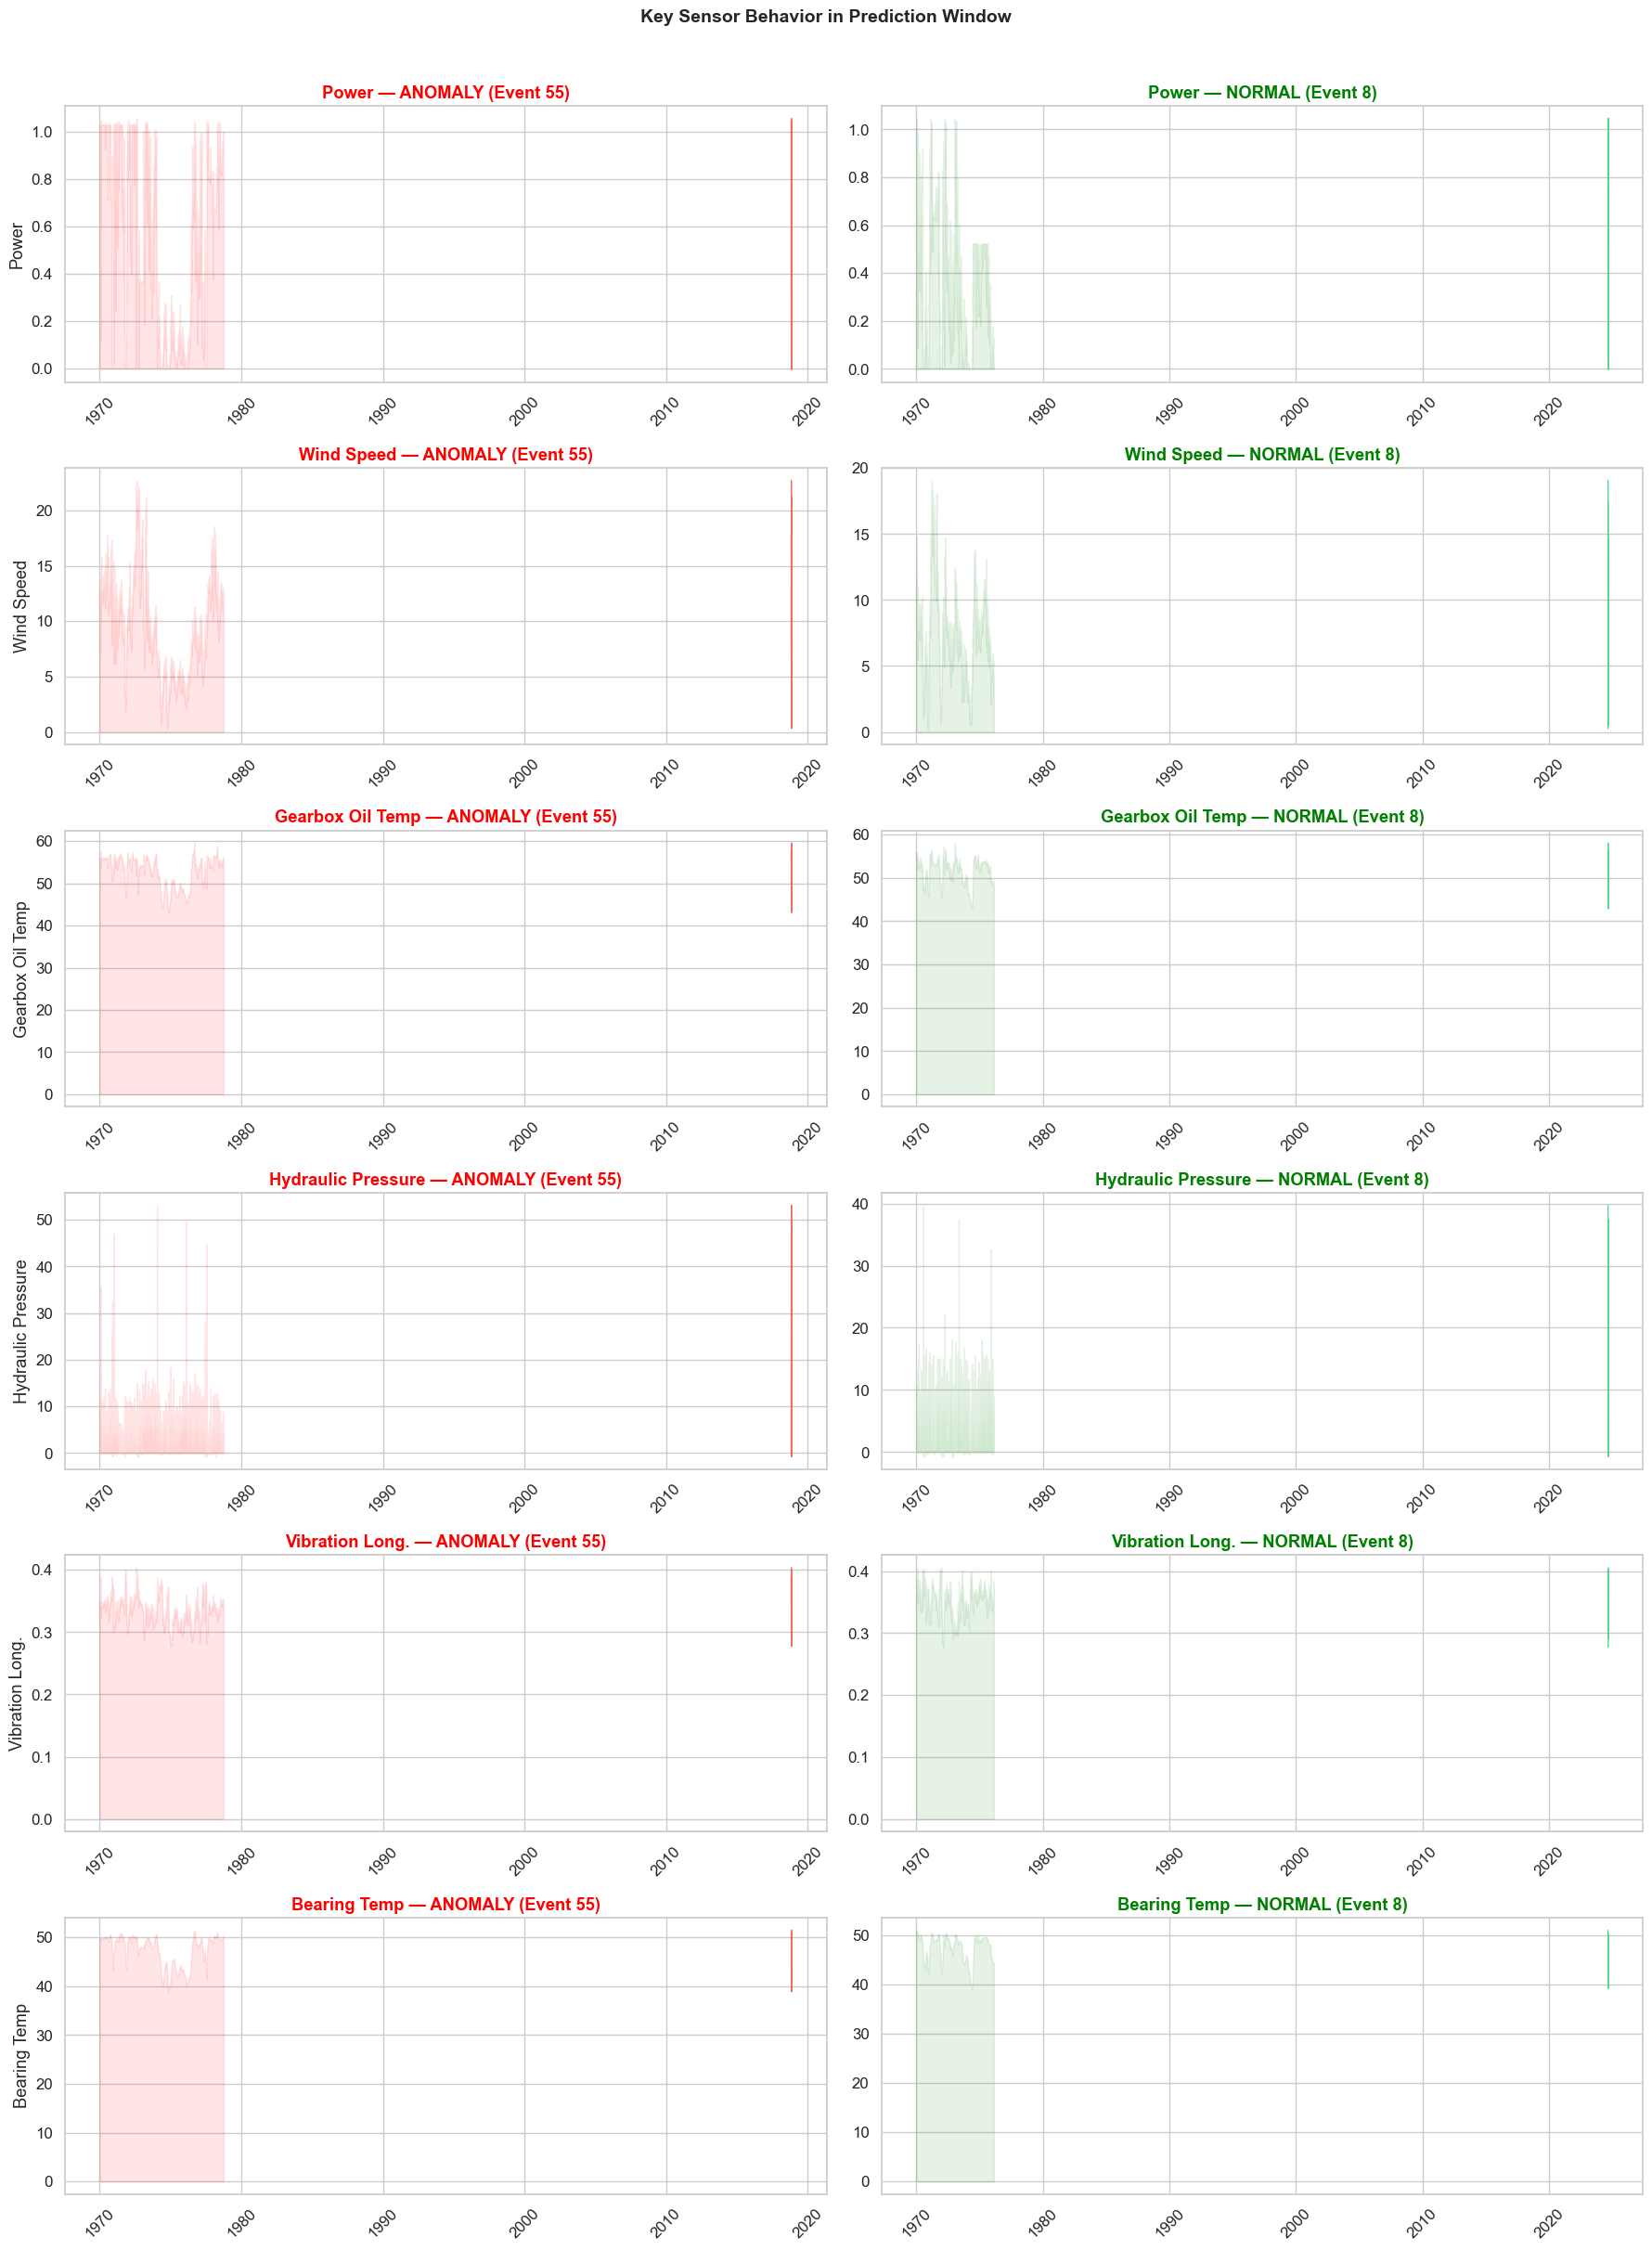

In [13]:
# Key sensors to monitor (domain knowledge)
key_sensors = {
    'Power': 'power_2_avg',
    'Wind Speed': 'wind_speed_236_avg',
    'Gearbox Oil Temp': 'sensor_186_avg',
    'Hydraulic Pressure': 'sensor_48_avg',
    'Vibration Long.': 'sensor_90_avg',
    'Bearing Temp': 'sensor_196_avg',
}

fig, axes = plt.subplots(len(key_sensors), 2, figsize=(18, 4 * len(key_sensors)))

anom_id = sample_anomaly_ids[0]
norm_id = sample_normal_ids[0]

df_anom, ev_anom = load_dataset(anom_id)
df_norm, ev_norm = load_dataset(norm_id)

pred_anom = df_anom[df_anom['train_test'] == 'prediction'].copy()
pred_norm = df_norm[df_norm['train_test'] == 'prediction'].copy()

for i, (name, col) in enumerate(key_sensors.items()):
    # Anomaly event
    if col in pred_anom.columns:
        axes[i, 0].plot(pred_anom['time_stamp'].values, pred_anom[col].values,
                       color='#e74c3c', linewidth=0.8, alpha=0.8)
        axes[i, 0].fill_between(range(len(pred_anom)), pred_anom[col].values,
                               alpha=0.1, color='red')
    axes[i, 0].set_title(f'{name} — ANOMALY (Event {anom_id})', fontweight='bold', color='red')
    axes[i, 0].set_ylabel(name)
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    # Normal event
    if col in pred_norm.columns:
        axes[i, 1].plot(pred_norm['time_stamp'].values, pred_norm[col].values,
                       color='#2ecc71', linewidth=0.8, alpha=0.8)
        axes[i, 1].fill_between(range(len(pred_norm)), pred_norm[col].values,
                               alpha=0.1, color='green')
    axes[i, 1].set_title(f'{name} — NORMAL (Event {norm_id})', fontweight='bold', color='green')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Key Sensor Behavior in Prediction Window', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

del df_anom, df_norm

## 9. DBSCAN-Based Outlier Removal & Power Curve Fitting

Before DBSCAN: 43197 points
Inliers: 43122 | Outliers: 75 (0.2%)


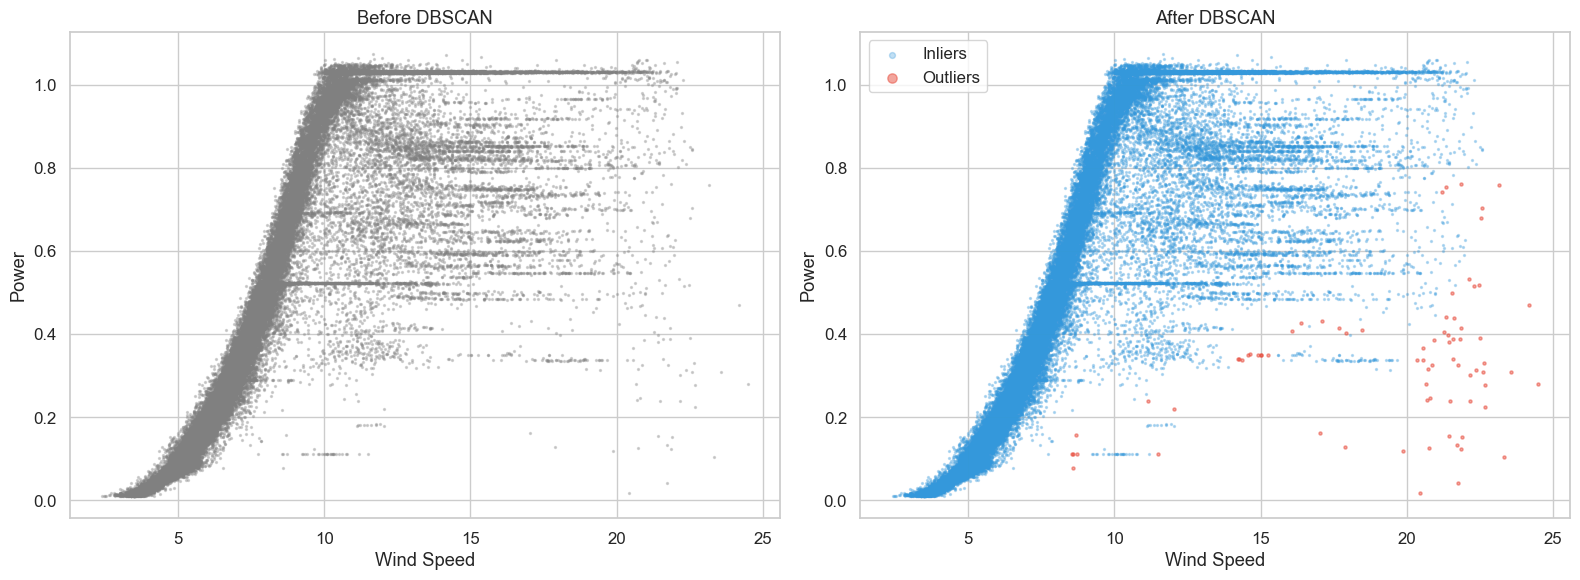

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load one anomaly dataset for cleaning demonstration
df_demo, ev_demo = load_dataset(sample_anomaly_ids[0])
df_train = df_demo[df_demo['train_test'] == 'train'].copy()
df_train_healthy = df_train[df_train['status_type_id'] == 0].copy()

ws_col, pw_col = 'wind_speed_236_avg', 'power_2_avg'

# Prepare data for DBSCAN
clean_data = df_train_healthy[[ws_col, pw_col]].dropna()
clean_data = clean_data[(clean_data[ws_col] > 0) & (clean_data[pw_col] > 0.01)]

# Standardize for DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_data[[ws_col, pw_col]])

# DBSCAN
db = DBSCAN(eps=0.15, min_samples=10)
clean_data['cluster'] = db.fit_predict(X_scaled)

inliers = clean_data[clean_data['cluster'] != -1]
outliers = clean_data[clean_data['cluster'] == -1]

print(f'Before DBSCAN: {len(clean_data)} points')
print(f'Inliers: {len(inliers)} | Outliers: {len(outliers)} ({len(outliers)/len(clean_data)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(clean_data[ws_col], clean_data[pw_col], s=2, alpha=0.3, c='gray')
axes[0].set_title('Before DBSCAN')
axes[0].set_xlabel('Wind Speed'); axes[0].set_ylabel('Power')

axes[1].scatter(inliers[ws_col], inliers[pw_col], s=2, alpha=0.3, c='#3498db', label='Inliers')
axes[1].scatter(outliers[ws_col], outliers[pw_col], s=5, alpha=0.5, c='#e74c3c', label='Outliers')
axes[1].set_title('After DBSCAN')
axes[1].set_xlabel('Wind Speed'); axes[1].set_ylabel('Power')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

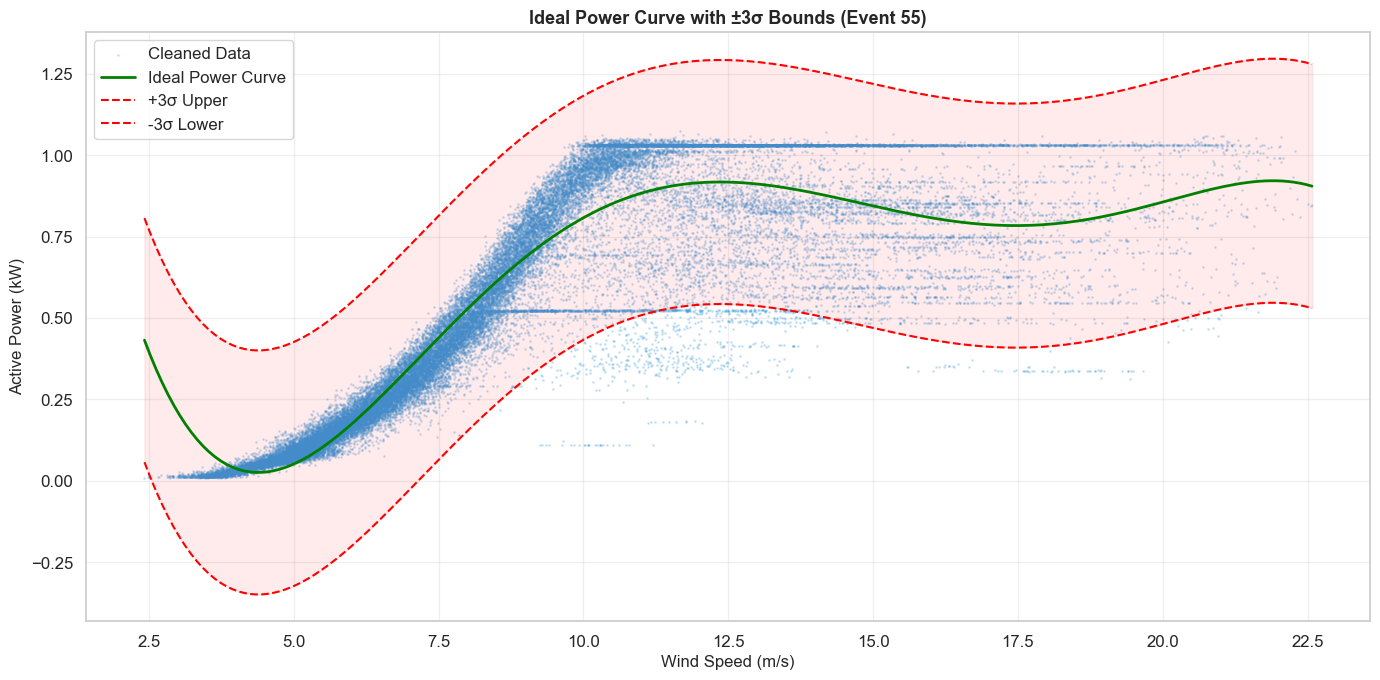

Residual std (σ): 0.12 kW
Points within ±3σ: 42292 / 43122


In [16]:
# Fit ideal power curve using polynomial on DBSCAN-cleaned data
from numpy.polynomial import polynomial as P

x = inliers[ws_col].values
y = inliers[pw_col].values

# Fit degree-5 polynomial
coeffs = np.polyfit(x, y, deg=5)
poly_fn = np.poly1d(coeffs)

# Compute residuals and sigma
y_pred = poly_fn(x)
residuals = y - y_pred
sigma = residuals.std()

# Plot power curve with bounds
x_sorted = np.linspace(x.min(), x.max(), 200)
y_ideal = poly_fn(x_sorted)

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(x, y, s=1, alpha=0.2, c='#3498db', label='Cleaned Data')
ax.plot(x_sorted, y_ideal, color='green', linewidth=2, label='Ideal Power Curve')
ax.plot(x_sorted, y_ideal + 3*sigma, color='red', linewidth=1.5, linestyle='--', label='+3σ Upper')
ax.plot(x_sorted, y_ideal - 3*sigma, color='red', linewidth=1.5, linestyle='--', label='-3σ Lower')
ax.fill_between(x_sorted, y_ideal - 3*sigma, y_ideal + 3*sigma, alpha=0.08, color='red')
ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax.set_ylabel('Active Power (kW)', fontsize=12)
ax.set_title(f'Ideal Power Curve with ±3σ Bounds (Event {sample_anomaly_ids[0]})', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Residual std (σ): {sigma:.2f} kW')
print(f'Points within ±3σ: {((residuals >= -3*sigma) & (residuals <= 3*sigma)).sum()} / {len(residuals)}')

## 10. Correlation Analysis — Key Sensor Groups

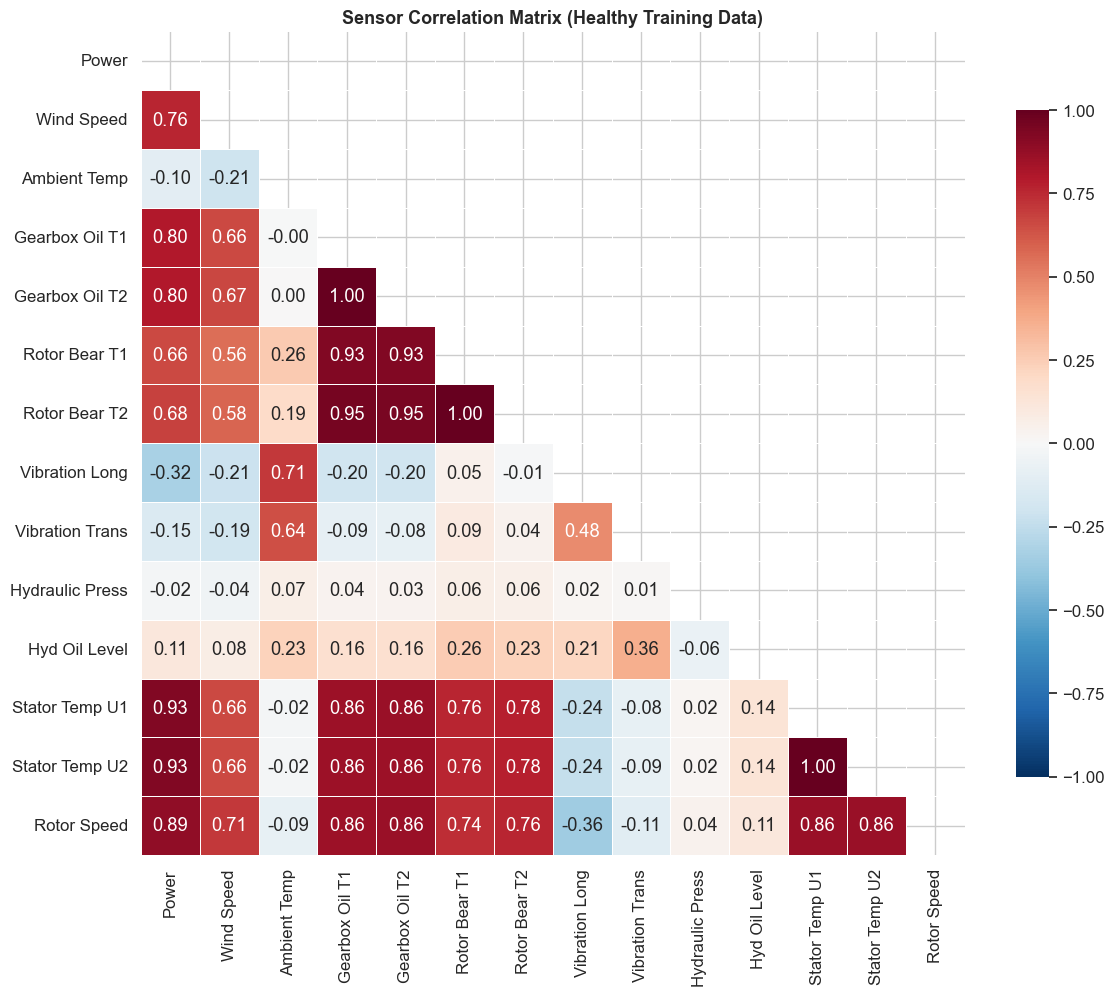

In [17]:
# Select key sensor averages for correlation analysis
corr_sensors = [
    'power_2_avg', 'wind_speed_236_avg', 'sensor_7_avg',     # Power, Wind, Ambient Temp
    'sensor_186_avg', 'sensor_187_avg',                        # Gearbox oil temps
    'sensor_196_avg', 'sensor_197_avg',                        # Rotor bearing temps
    'sensor_90_avg', 'sensor_92_avg',                          # Vibration
    'sensor_48_avg', 'sensor_74_avg',                          # Hydraulic pressure & oil level
    'sensor_199_avg', 'sensor_200_avg',                        # Stator winding temps
    'sensor_144_avg',                                           # Rotor speed
]

# Use the already-loaded training data
corr_cols_present = [c for c in corr_sensors if c in df_train_healthy.columns]
corr_matrix = df_train_healthy[corr_cols_present].corr()

# Rename for readability
rename_map = {
    'power_2_avg': 'Power', 'wind_speed_236_avg': 'Wind Speed',
    'sensor_7_avg': 'Ambient Temp', 'sensor_186_avg': 'Gearbox Oil T1',
    'sensor_187_avg': 'Gearbox Oil T2', 'sensor_196_avg': 'Rotor Bear T1',
    'sensor_197_avg': 'Rotor Bear T2', 'sensor_90_avg': 'Vibration Long',
    'sensor_92_avg': 'Vibration Trans', 'sensor_48_avg': 'Hydraulic Press',
    'sensor_74_avg': 'Hyd Oil Level', 'sensor_199_avg': 'Stator Temp U1',
    'sensor_200_avg': 'Stator Temp U2', 'sensor_144_avg': 'Rotor Speed',
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Correlation Matrix (Healthy Training Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Feature Selection Pipeline — Identifying Useful Sensors

In [18]:
# Step 1: Drop columns with >80% zeros
zero_pct = (df_train_healthy[sensor_cols] == 0).mean() * 100
cols_high_zero = zero_pct[zero_pct >= 80].index.tolist()

# Step 2: Drop constant columns (zero variance)
variance = df_train_healthy[sensor_cols].var()
cols_zero_var = variance[variance == 0].index.tolist()

# Step 3: Drop counter-type features
counter_sensors = feat_desc[feat_desc['is_counter'] == True]['sensor_name'].tolist()
cols_counter = []
for s in counter_sensors:
    cols_counter.extend([c for c in sensor_cols if c.startswith(s)])

# Step 4: Drop highly correlated features (|r| > 0.95)
avg_cols = [c for c in sensor_cols if c.endswith('_avg') and c not in cols_high_zero + cols_zero_var + cols_counter]
if len(avg_cols) > 0:
    corr_full = df_train_healthy[avg_cols].corr().abs()
    upper_tri = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
    cols_high_corr_avg = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
else:
    cols_high_corr_avg = []

# Combine all columns to drop
all_drop = set(cols_high_zero + cols_zero_var + cols_counter)
remaining = [c for c in sensor_cols if c not in all_drop]

print(f'=== Feature Selection Summary ===')
print(f'  Original sensor columns:     {len(sensor_cols)}')
print(f'  Dropped (>80% zero):         {len(cols_high_zero)}')
print(f'  Dropped (zero variance):     {len(cols_zero_var)}')
print(f'  Dropped (counter features):  {len(cols_counter)}')
print(f'  Highly correlated (|r|>0.95): {len(cols_high_corr_avg)} (avg cols only, informational)')
print(f'  ─────────────────────────────')
print(f'  Remaining sensor columns:    {len(remaining)}')

=== Feature Selection Summary ===
  Original sensor columns:     952
  Dropped (>80% zero):         38
  Dropped (zero variance):     12
  Dropped (counter features):  0
  Highly correlated (|r|>0.95): 146 (avg cols only, informational)
  ─────────────────────────────
  Remaining sensor columns:    914


## 12. Pre-Failure Window Detection Strategy
Examine what happens in the prediction window for anomaly events — can we see degradation patterns?

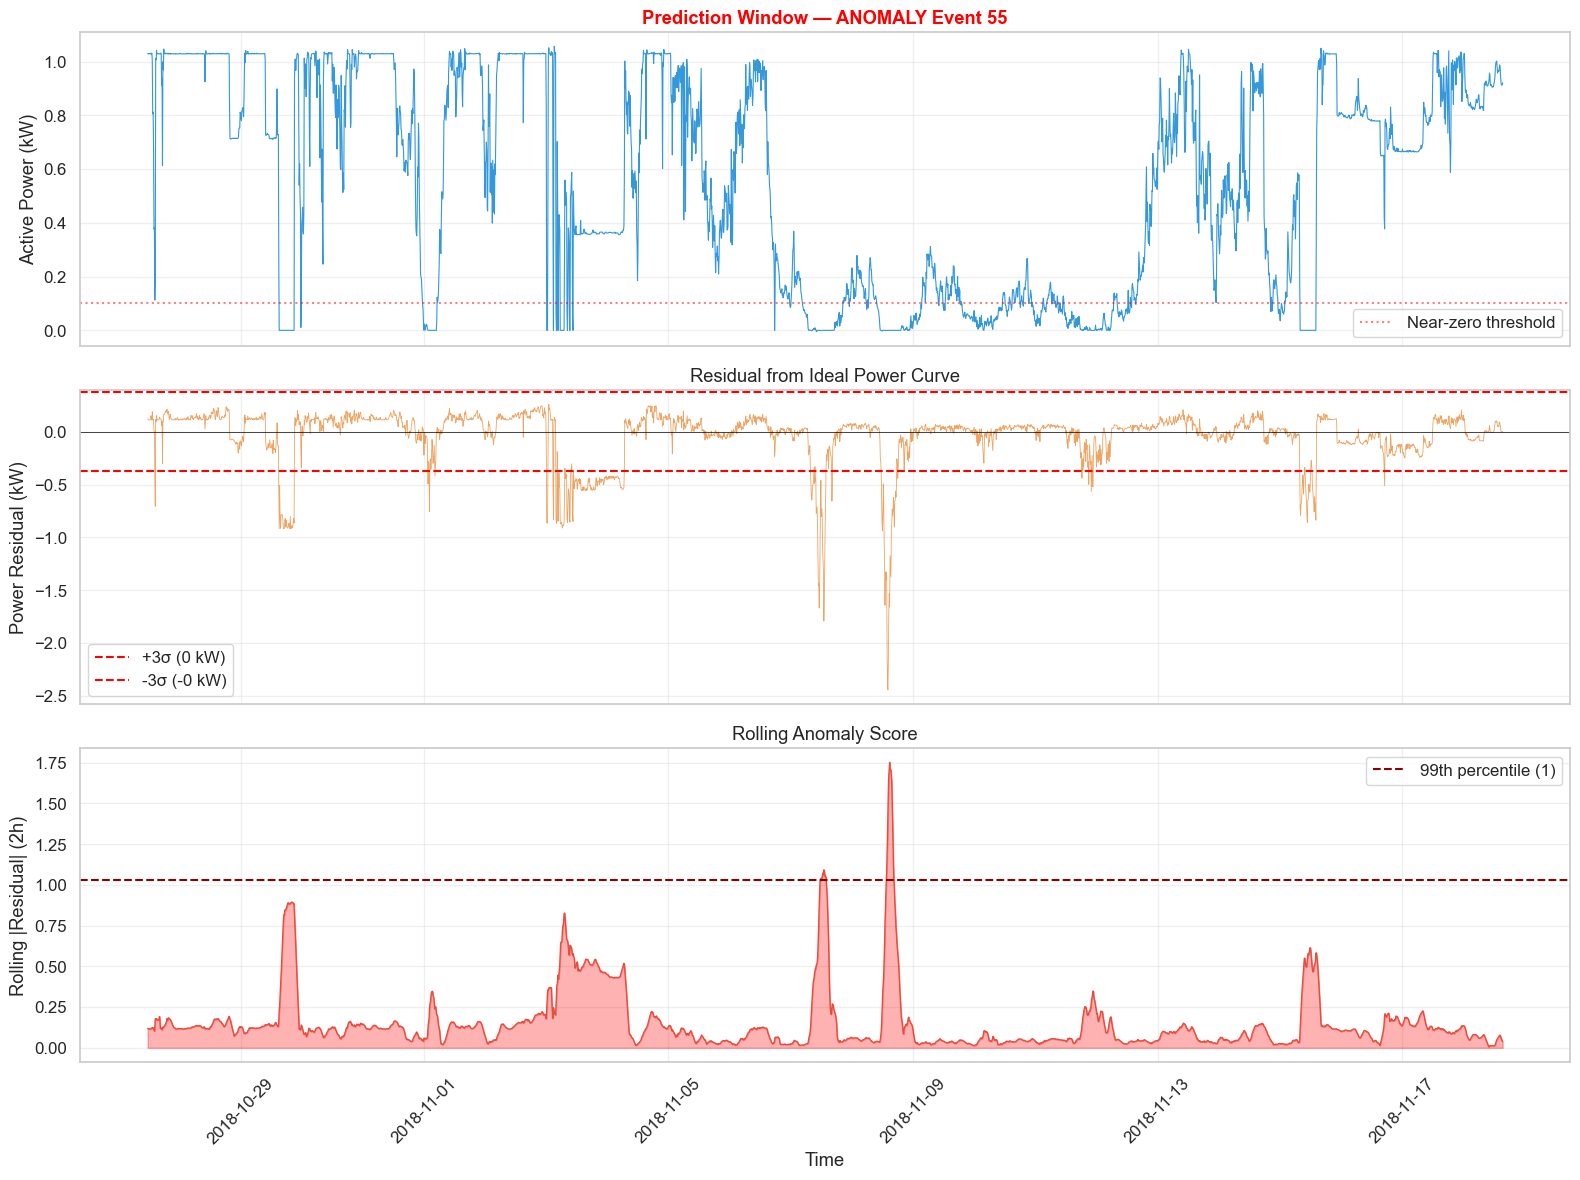

In [19]:
# Power curve residual analysis in prediction window
df_pred = df_demo[df_demo['train_test'] == 'prediction'].copy()
df_pred['ideal_power'] = poly_fn(df_pred[ws_col].values)
df_pred['residual'] = df_pred[pw_col] - df_pred['ideal_power']

# Rolling anomaly score (distance from ideal)
df_pred['abs_residual'] = df_pred['residual'].abs()
df_pred['rolling_residual'] = df_pred['abs_residual'].rolling(window=12, min_periods=1).mean()  # 2-hour window

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Power output
axes[0].plot(df_pred['time_stamp'], df_pred[pw_col], color='#3498db', linewidth=0.8)
axes[0].set_ylabel('Active Power (kW)')
axes[0].set_title(f'Prediction Window — ANOMALY Event {sample_anomaly_ids[0]}', fontweight='bold', color='red')
axes[0].axhline(y=0.1, color='red', linestyle=':', alpha=0.5, label='Near-zero threshold')
axes[0].legend()

# Raw residuals
axes[1].plot(df_pred['time_stamp'], df_pred['residual'], color='#e67e22', linewidth=0.6, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhline(3*sigma, color='red', linestyle='--', label=f'+3σ ({3*sigma:.0f} kW)')
axes[1].axhline(-3*sigma, color='red', linestyle='--', label=f'-3σ ({-3*sigma:.0f} kW)')
axes[1].set_ylabel('Power Residual (kW)')
axes[1].set_title('Residual from Ideal Power Curve')
axes[1].legend()

# Rolling anomaly score
axes[2].fill_between(df_pred['time_stamp'], df_pred['rolling_residual'], alpha=0.3, color='red')
axes[2].plot(df_pred['time_stamp'], df_pred['rolling_residual'], color='#e74c3c', linewidth=1)
threshold_99 = df_pred['rolling_residual'].quantile(0.99)
axes[2].axhline(threshold_99, color='darkred', linestyle='--', label=f'99th percentile ({threshold_99:.0f})')
axes[2].set_ylabel('Rolling |Residual| (2h)')
axes[2].set_xlabel('Time')
axes[2].set_title('Rolling Anomaly Score')
axes[2].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

del df_demo

## 13. Cross-Event Summary — All 58 Datasets
Quick scan across ALL events to get aggregate statistics without loading full data into memory.

In [20]:
# Lightweight scan of all 58 datasets
all_event_summary = []

for _, ev_row in event_df.iterrows():
    eid = ev_row['event_id']
    fpath = DATASET_DIR / f'{eid}.csv'
    if not fpath.exists():
        continue
    
    # Load only metadata + key sensors (memory efficient)
    usecols = meta_cols + ['power_2_avg', 'wind_speed_236_avg', 'sensor_186_avg', 'sensor_90_avg']
    df_t = pd.read_csv(fpath, sep=';', usecols=usecols, parse_dates=['time_stamp'])
    
    train = df_t[df_t['train_test'] == 'train']
    pred = df_t[df_t['train_test'] == 'prediction']
    
    # Compute summary stats for prediction window
    summary = {
        'event_id': eid,
        'label': ev_row['event_label'],
        'asset_id': df_t['asset_id'].iloc[0],
        'n_train': len(train),
        'n_pred': len(pred),
        'pred_power_mean': pred['power_2_avg'].mean(),
        'pred_power_std': pred['power_2_avg'].std(),
        'pred_power_zero_pct': (pred['power_2_avg'] <= 0.1).mean() * 100,
        'pred_wind_mean': pred['wind_speed_236_avg'].mean(),
        'pred_status_0_pct': (pred['status_type_id'] == 0).mean() * 100,
        'train_status_0_pct': (train['status_type_id'] == 0).mean() * 100,
    }
    all_event_summary.append(summary)
    del df_t
    
    if len(all_event_summary) % 10 == 0:
        print(f'  Processed {len(all_event_summary)}/{len(event_df)} events...')

summary_df = pd.DataFrame(all_event_summary)
print(f'\nDone! Scanned {len(summary_df)} events.')
summary_df.head()

  Processed 10/58 events...
  Processed 20/58 events...
  Processed 30/58 events...
  Processed 40/58 events...
  Processed 50/58 events...

Done! Scanned 58 events.


,event_id,label,asset_id,n_train,n_pred,pred_power_mean,pred_power_std,pred_power_zero_pct,pred_wind_mean,pred_status_0_pct,train_status_0_pct
0,55,anomaly,50,52560,3193,0.555729,0.393353,21.327905,9.538223,96.648920,92.952816
1,81,anomaly,38,52560,1372,0.372200,0.308554,31.195335,9.775334,86.588921,84.684170
2,47,anomaly,21,52416,1577,0.474423,0.310173,19.277108,11.767691,96.322131,91.348062
3,12,anomaly,2,52560,3547,0.324141,0.388551,47.025655,6.734469,91.147449,94.339802
4,4,anomaly,34,52560,3889,0.216326,0.240987,41.964515,6.371664,90.794549,87.954718


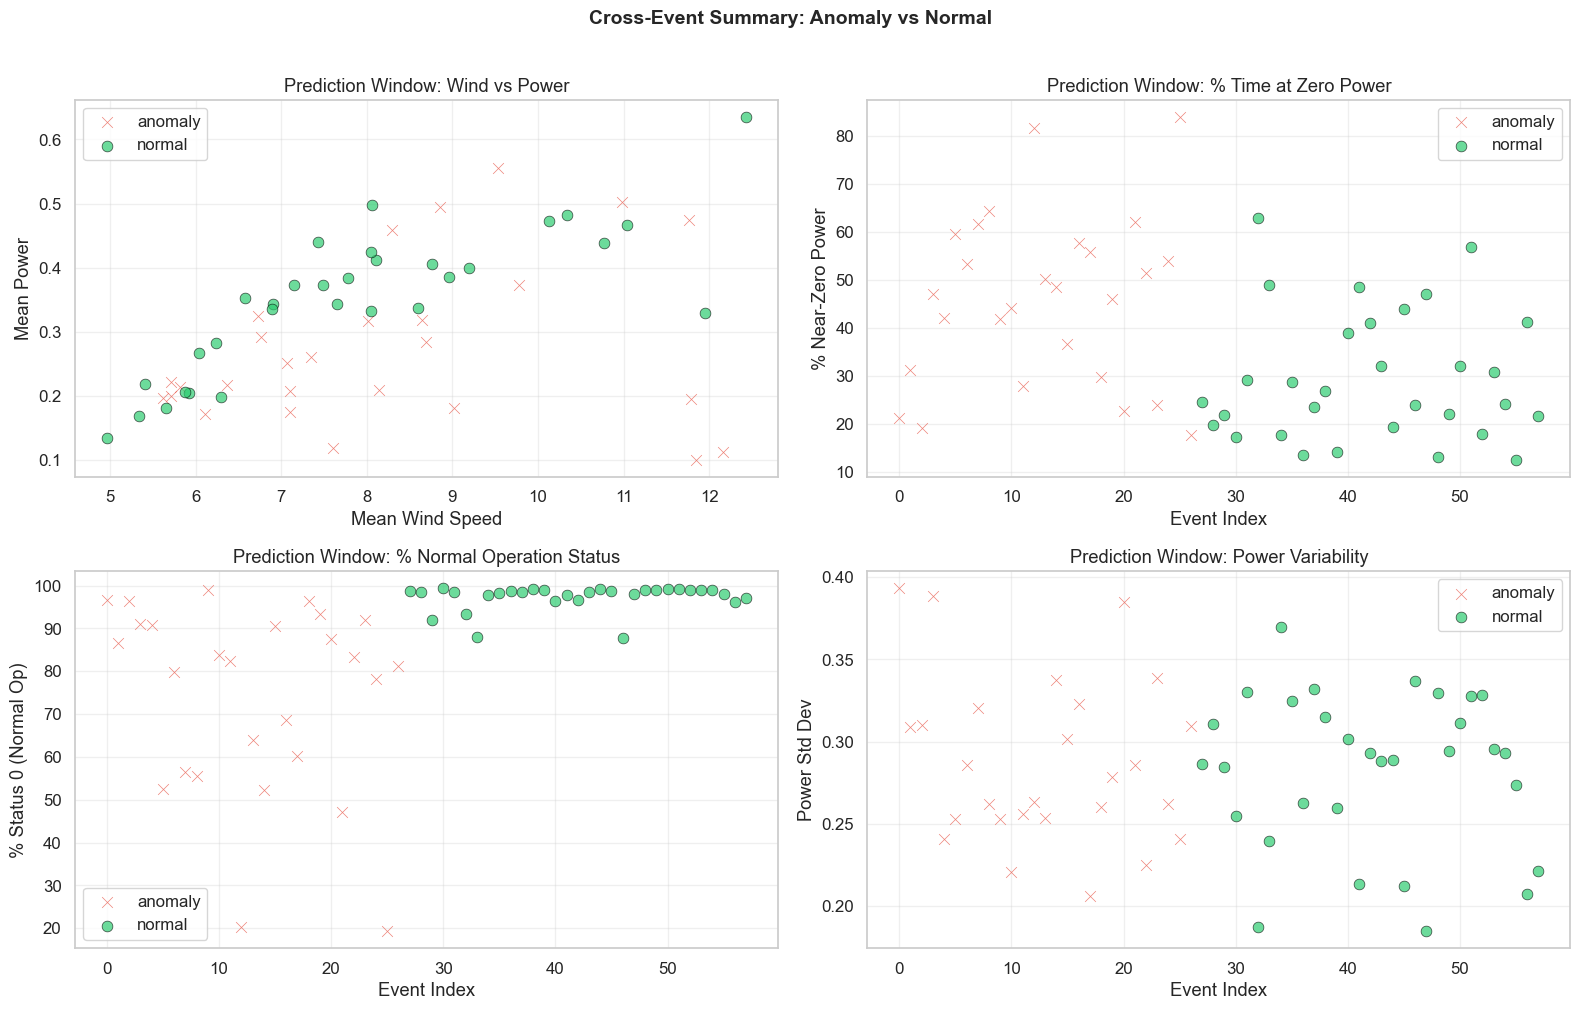

In [21]:
# Visualize cross-event patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for label, color, marker in [('anomaly', '#e74c3c', 'x'), ('normal', '#2ecc71', 'o')]:
    sub = summary_df[summary_df['label'] == label]
    
    axes[0,0].scatter(sub['pred_wind_mean'], sub['pred_power_mean'], 
                     c=color, marker=marker, s=60, alpha=0.7, label=label, edgecolors='black', linewidth=0.5)
    axes[0,1].scatter(sub.index, sub['pred_power_zero_pct'],
                     c=color, marker=marker, s=60, alpha=0.7, label=label, edgecolors='black', linewidth=0.5)
    axes[1,0].scatter(sub.index, sub['pred_status_0_pct'],
                     c=color, marker=marker, s=60, alpha=0.7, label=label, edgecolors='black', linewidth=0.5)
    axes[1,1].scatter(sub.index, sub['pred_power_std'],
                     c=color, marker=marker, s=60, alpha=0.7, label=label, edgecolors='black', linewidth=0.5)

axes[0,0].set_xlabel('Mean Wind Speed'); axes[0,0].set_ylabel('Mean Power')
axes[0,0].set_title('Prediction Window: Wind vs Power'); axes[0,0].legend()

axes[0,1].set_xlabel('Event Index'); axes[0,1].set_ylabel('% Near-Zero Power')
axes[0,1].set_title('Prediction Window: % Time at Zero Power'); axes[0,1].legend()

axes[1,0].set_xlabel('Event Index'); axes[1,0].set_ylabel('% Status 0 (Normal Op)')
axes[1,0].set_title('Prediction Window: % Normal Operation Status'); axes[1,0].legend()

axes[1,1].set_xlabel('Event Index'); axes[1,1].set_ylabel('Power Std Dev')
axes[1,1].set_title('Prediction Window: Power Variability'); axes[1,1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.suptitle('Cross-Event Summary: Anomaly vs Normal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# Statistical comparison: anomaly vs normal prediction windows
print('=== Anomaly vs Normal — Prediction Window Statistics ===')
compare_cols = ['pred_power_mean', 'pred_power_std', 'pred_power_zero_pct', 
                'pred_wind_mean', 'pred_status_0_pct', 'n_pred']
comparison = summary_df.groupby('label')[compare_cols].agg(['mean', 'median', 'std']).round(2)
print(comparison.to_string())

=== Anomaly vs Normal — Prediction Window Statistics ===
        pred_power_mean              pred_power_std              pred_power_zero_pct               pred_wind_mean              pred_status_0_pct                 n_pred                 
                   mean median   std           mean median   std                mean median    std           mean median   std              mean median    std     mean  median      std
label                                                                                                                                                                                   
anomaly            0.28   0.22  0.13           0.29   0.28  0.05               45.76  47.03  17.76           8.24   8.01  2.05             74.29  82.39  22.26  2884.78  2320.0  2268.85
normal             0.35   0.35  0.11           0.28   0.29  0.05               29.57  24.49  13.49           7.87   7.65  1.98             97.33  98.56   3.01  2601.26  2573.0   620.21


## 14. Data Cleaning Pipeline — Final Summary

### Cleaning Steps Established:
1. **Status filtering**: Keep only `status_type_id == 0` for training (healthy operation)
2. **DBSCAN outlier removal**: In wind-power space (eps=0.15, min_samples=10)
3. **Power curve fitting**: Degree-5 polynomial → residual-based ±3σ filtering
4. **Feature elimination**: Drop >80% zero cols, zero-variance cols, counter features
5. **Missing values**: Forward-fill then backward-fill for temporal continuity

### Key Findings:
- Anomaly events show **higher % of near-zero power** and **lower status_0 %** in prediction windows
- Power curve residuals are a strong anomaly signal
- Temperature and vibration sensors diverge between anomaly/normal events
- The 58 events span multiple turbines (different asset_ids)
- Event durations vary widely (hours to weeks)

In [23]:
# Save the event summary for use in modeling
summary_df.to_csv('event_summary_eda.csv', index=False)
print('Saved: event_summary_eda.csv')
print(f'\nFinal dataset overview:')
print(f'  Total events: {len(summary_df)}')
print(f'  Anomaly: {(summary_df["label"]=="anomaly").sum()}')
print(f'  Normal:  {(summary_df["label"]=="normal").sum()}')
print(f'  Unique turbines: {summary_df["asset_id"].nunique()}')
print(f'  Useful sensors (after cleaning): ~{len(remaining)}')

Saved: event_summary_eda.csv

Final dataset overview:
  Total events: 58
  Anomaly: 27
  Normal:  31
  Unique turbines: 22
  Useful sensors (after cleaning): ~914
